# Machine Learning Project : Credit-Card fraud detection 

In [2]:
# Data packages and Libraries :

import os
import zipfile
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import joblib

In [3]:
# Zip file PATH and Configuration

ZIP_PATH = "C:\\Users\\rajua\\OneDrive\Desktop\\project . ML\\archive.zip"    # path to uploaded archive (provided in conversation)
CSV_PATH = None                       # set to a path if you know the CSV (overrides ZIP_PATH)
RANDOM_STATE = 42
OUTPUT_DIR = 'C:\\Users\\rajua\\OneDrive\Desktop\\project . ML'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# Helpers and Functions 

def extract_csv_from_zip(zip_path, out_dir="C:\\Users\\rajua\\OneDrive\Desktop\\project . ML"):
    """Extracts zip and returns a list of CSV file paths found inside."""
    csv_files = []
    if not os.path.exists(zip_path):
        print(f"Zip not found at {zip_path}")
        return csv_files
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)
        for name in z.namelist():
            if name.lower().endswith('.csv'):
                csv_files.append(os.path.join(out_dir, name))
    return csv_files

In [4]:
def find_best_csv(csv_files):
    """Heuristic: prefer files named 'credit', 'fraud', or containing many rows/columns."""
    if not csv_files:
        return None
    # prioritize filenames
    for fname in csv_files:
        if any(key in os.path.basename(fname).lower() for key in ['credit', 'fraud', 'transaction']):
            return fname
    # otherwise take largest file by size
    csv_files_sorted = sorted(csv_files, key=lambda p: os.path.getsize(p), reverse=True)
    return csv_files_sorted[0]


In [5]:
# Load Data :

if CSV_PATH and os.path.exists(CSV_PATH):
    data_path = CSV_PATH
else:
    print('Looking for CSV files inside the provided zip...')
    csvs = extract_csv_from_zip(ZIP_PATH, out_dir='/mnt/data')
    if not csvs:
        raise FileNotFoundError('No CSV files found in the provided archive. Place a CSV or update CSV_PATH.')
    data_path = find_best_csv(csvs)

print(f'Using data file: {data_path}')

df = pd.read_csv(data_path)
print('\nDataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Looking for CSV files inside the provided zip...
Using data file: /mnt/data\fraudTest.csv

Dataset shape: (555719, 23)

Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [6]:
# Quick look at the data : 

print("first 5 rowa : ")
print(df.head())

first 5 rowa : 
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Unio

In [7]:
# Simple EDA :(checking of missing values)

print('Checking for missing values:')
print(df.isnull().sum().sort_values(ascending=False).head(20))

Checking for missing values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
dtype: int64


In [8]:
# find target column - common names : 'names' , "is_fraud", "fraud" , "target" 

possible_targets = ['Class', 'isFraud', 'fraud', 'is_fraud', 'target', 'label']
cols_lower = [c.lower() for c in df.columns]
TARGET_COL = None
for t in possible_targets:
    if t.lower() in cols_lower:
        TARGET_COL = df.columns[cols_lower.index(t.lower())]
        break



In [9]:
if TARGET_COL is None:
    # ask heuristic: if there is a column with only 0/1
    for c in df.columns:
        unique_vals = set(df[c].dropna().unique())
        if unique_vals <= {0, 1}:
            TARGET_COL = c
            break

In [10]:
if TARGET_COL is None:
    raise ValueError('Could not find a binary target column automatically. Please set TARGET_COL manually.')

print(f'Using target column: {TARGET_COL}')

Using target column: is_fraud


In [11]:
# show class distribution  : 
 
print('Class distribution\n:')
print(df[TARGET_COL].value_counts())

Class distribution
:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


## ADVANCED EDA : 

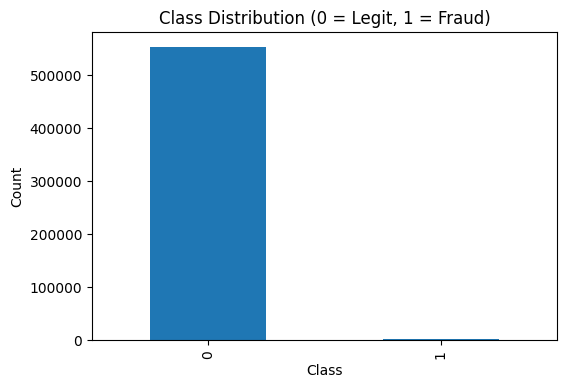

In [12]:
# Class Distribution plot : 

plt.figure(figsize=(6,4))
df[TARGET_COL].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


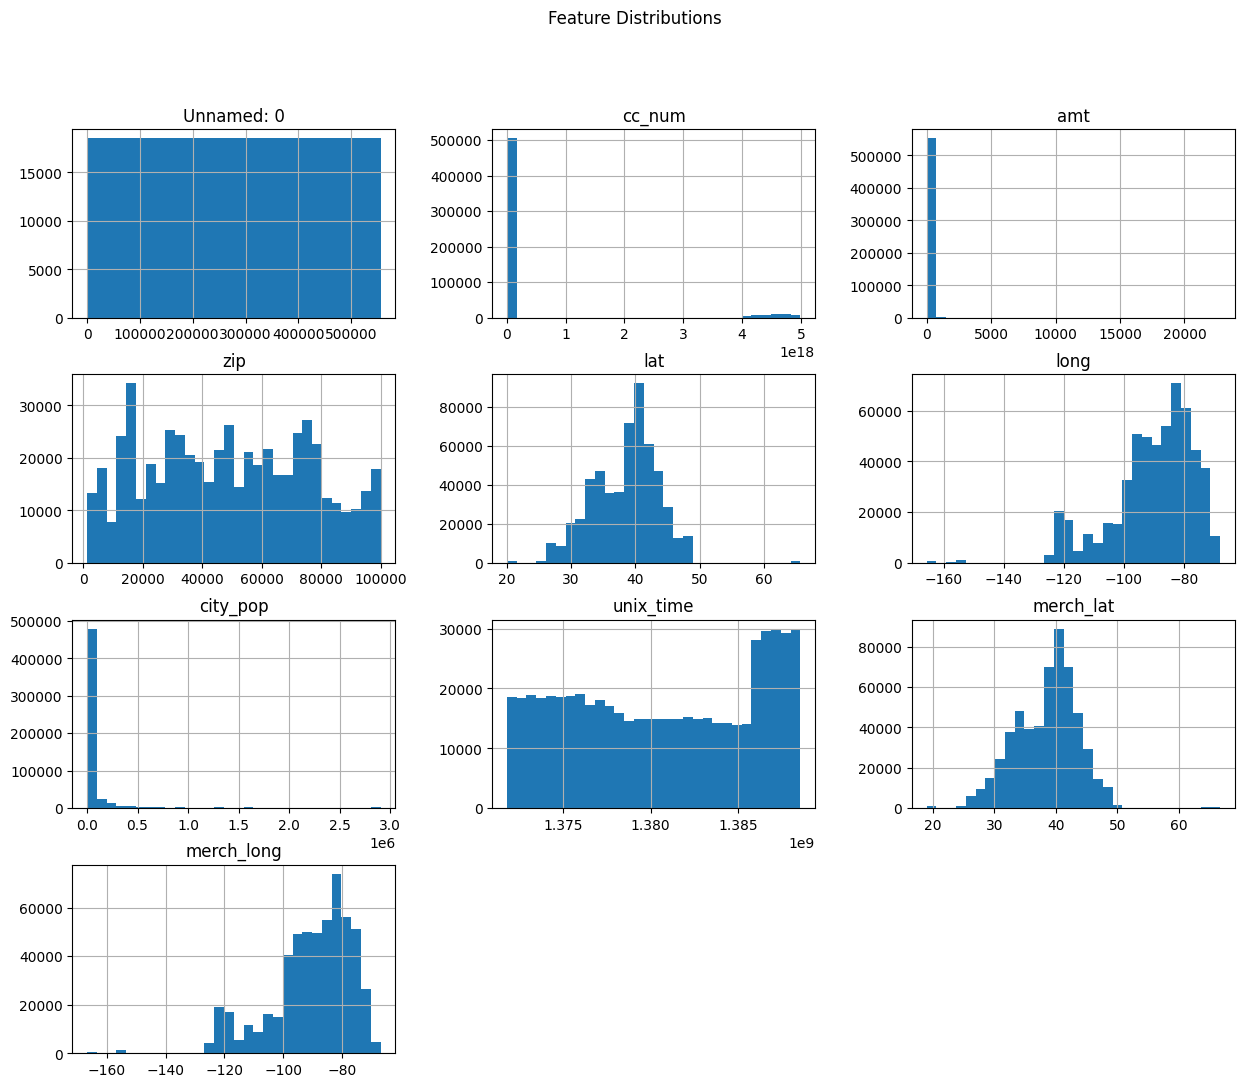

In [13]:
# Fearture Distribution (Histogram of Features) : 

df.drop(columns=[TARGET_COL]).hist(
    figsize=(15,12),
    bins=30
)
plt.suptitle("Feature Distributions")
plt.show()


In [ ]:
# Transaction Amount Analysis : 

if 'Amount' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[TARGET_COL], y=df['Amount'])
    plt.title("Transaction Amount vs Class")
    plt.xlabel("Class (0 = Legit, 1 = Fraud)")
    plt.ylabel("Transaction Amount")
    plt.show()


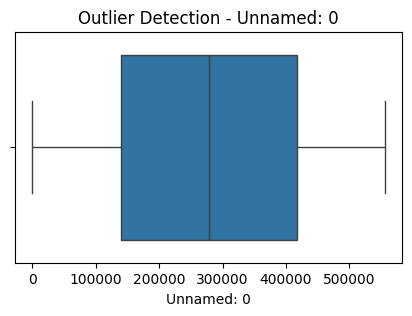

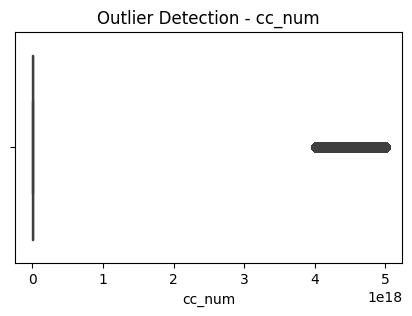

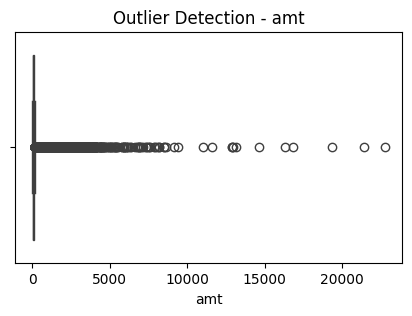

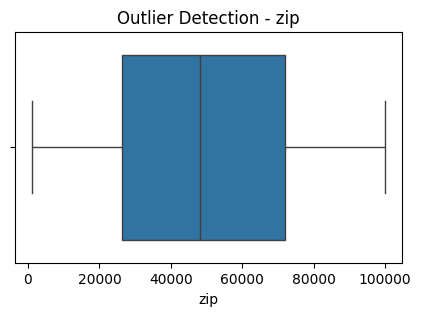

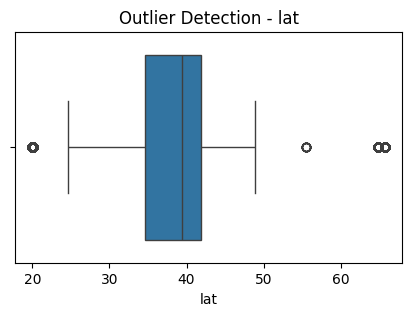

In [20]:
# Outlier Detection :

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols[:5]:  # limit to first 5 to avoid clutter
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()


In [ ]:
# Preprocesseing data : 

X = df.drop(columns=[TARGET_COL])  # Separate feature and targets
y = df[TARGET_COL].astype(int)

In [ ]:
# Drop non-numeric columns if any (simple approach) — user can refine : 

non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric} (you can preprocess them instead)")
    X = X.drop(columns=non_numeric)

# If there is an 'Time' column and 'Amount', typical creditcard data has these — we scale Amount
if 'Amount' in X.columns:
    # scale Amount separately
    scaler_amount = StandardScaler()
    X['Amount_scaled'] = scaler_amount.fit_transform(X[['Amount']])
    X = X.drop(columns=['Amount'])

Dropping non-numeric columns: ['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'] (you can preprocess them instead)


In [ ]:
# Standardize Features  : 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train - test split  : 

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('\nTrain positive ratio:', y_train.mean(), 'Test positive ratio:', y_test.mean())

# Handle class imbalance using SMOTE on training set
print('\nPerforming SMOTE on training set...')
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('After resampling, class counts:', np.bincount(y_train_res))


Train positive ratio: 0.003859866164314233 Test positive ratio: 0.003859857482185273

Performing SMOTE on training set...
After resampling, class counts: [442859 442859]


In [ ]:
# Models to try : 

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

results = {}


In [ ]:
for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    report = classification_report(y_test, y_pred, digits=4)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {
        'model': model,
        'report': report,
        'auc': auc,
        'cm': cm,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(report)
    print(f'ROC-AUC: {auc:.4f}')
    print('Confusion matrix:\n', cm)

    # save model
    model_path = os.path.join(OUTPUT_DIR, f'{name}.joblib')
    joblib.dump(model, model_path)
    print(f'Model saved to: {model_path}')

# Save scalers too
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))
if 'scaler_amount' in globals():
    joblib.dump(scaler_amount, os.path.join(OUTPUT_DIR, 'scaler_amount.joblib'))
print('\nSaved scalers to output folder.')


Training LogisticRegression...
              precision    recall  f1-score   support

           0     0.9989    0.9459    0.9717    110715
           1     0.0498    0.7319    0.0933       429

    accuracy                         0.9451    111144
   macro avg     0.5244    0.8389    0.5325    111144
weighted avg     0.9952    0.9451    0.9683    111144

ROC-AUC: 0.8491
Confusion matrix:
 [[104725   5990]
 [   115    314]]
Model saved to: C:\Users\rajua\OneDrive\Desktop\project . ML\LogisticRegression.joblib

Training DecisionTree...
              precision    recall  f1-score   support

           0     0.9987    0.9944    0.9965    110715
           1     0.3108    0.6550    0.4216       429

    accuracy                         0.9931    111144
   macro avg     0.6547    0.8247    0.7091    111144
weighted avg     0.9960    0.9931    0.9943    111144

ROC-AUC: 0.8247
Confusion matrix:
 [[110092    623]
 [   148    281]]
Model saved to: C:\Users\rajua\OneDrive\Desktop\project . ML\

ROC plot saved to: C:\Users\rajua\OneDrive\Desktop\project . ML\roc_curves.png


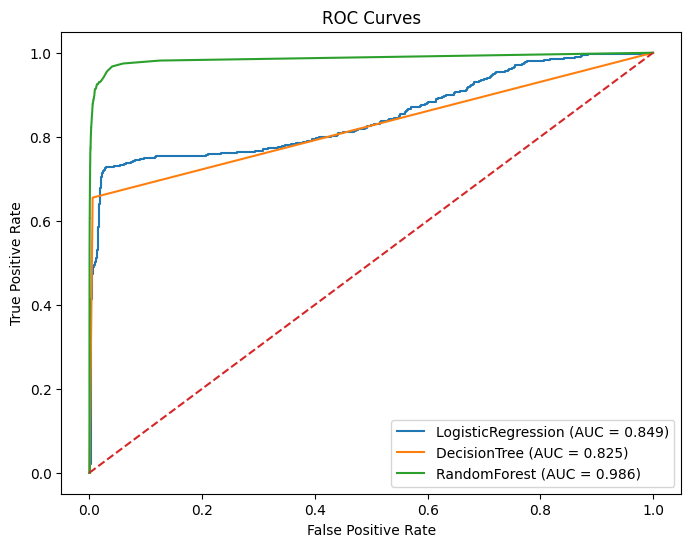

In [ ]:
# PLOT ROC Curves : 

plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {res["auc"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
roc_path = os.path.join(OUTPUT_DIR, 'roc_curves.png')
plt.savefig(roc_path, bbox_inches='tight')
print(f'ROC plot saved to: {roc_path}')

In [ ]:
# save Results summary : 

print('\nSummary of model AUCs:')
for name, res in results.items():
    print(f'{name}: AUC = {res["auc"]:.4f}')

print(f'All outputs (models, scalers, plots) are in: {OUTPUT_DIR}')



Summary of model AUCs:
LogisticRegression: AUC = 0.8491
DecisionTree: AUC = 0.8247
RandomForest: AUC = 0.9864
All outputs (models, scalers, plots) are in: C:\Users\rajua\OneDrive\Desktop\project . ML


In [23]:
from sklearn.metrics import accuracy_score



In [26]:

# Accuracy's of three MOdels

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train model
    model.fit(X_train_res, y_train_res)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store accuracy
    results[name]['accuracy'] = acc

    # Print named accuracy
    print(f"{name} Accuracy : {acc:.4f}")



Training LogisticRegression...
LogisticRegression Accuracy : 0.9451

Training DecisionTree...
DecisionTree Accuracy : 0.9931

Training RandomForest...
RandomForest Accuracy : 0.9972


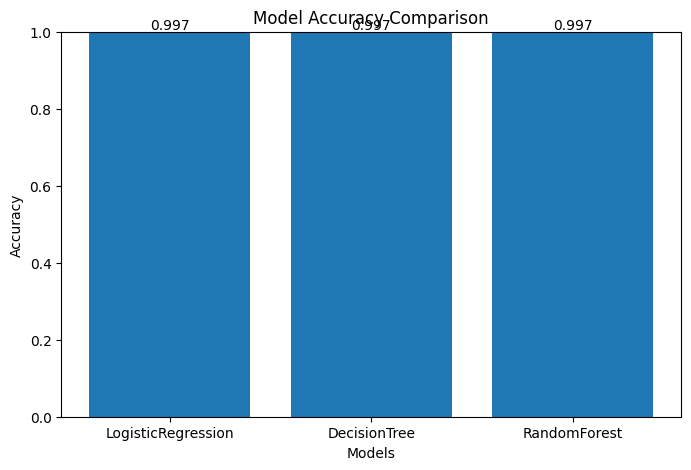

Accuracy bar plot saved to: C:\Users\rajua\OneDrive\Desktop\project . ML\model_accuracy_barplot.png


In [25]:
# BAR PLOT : Model Accurates 

model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

accuracy_plot_path = os.path.join(OUTPUT_DIR, 'model_accuracy_barplot.png')
plt.savefig(accuracy_plot_path, bbox_inches='tight')
plt.show()

print(f'Accuracy bar plot saved to: {accuracy_plot_path}')
